In [1]:
import json
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
RESULTS_DIR = Path("../../data/results/similarity_qed_pubchem")

In [3]:
# Define experiment groups: (model, folder_name)
GROUPS = [
    ("claude-sonnet-4.5", "claude-sonnet-4.5_full_xai"),
    ("claude-opus-4.5", "claude-opus-4.5_full_xai"),
    ("gpt-5.1", "gpt-5.1_full_xai"),
    ("gpt-4.1", "gpt-4.1_full_xai"),
    ("gpt-5.1_reasoning", "gpt-5.1_full_xai_medium"),
]

def load_trace(p):
    """Load trace from JSON file."""
    d = json.loads(p.read_text(encoding="utf-8"))
    return d["trace"] if isinstance(d, dict) and "trace" in d else d

# Load all data into a single DataFrame
rows = []
for model, folder in GROUPS:
    files = sorted((RESULTS_DIR / folder).glob("sim_qed_pubchem_*.json"))
    if not files:
        raise FileNotFoundError(f"No files in {RESULTS_DIR/folder} matching sim_qed_pubchem_*.json")
    
    for file_idx, file_path in enumerate(files):
        # Extract target molecule (e.g., "mol1", "mol2") from filename
        mol_match = re.search(r'mol\d+', file_path.name)
        target_molecule = mol_match.group() if mol_match else f"mol{file_idx}"
        
        trace = load_trace(file_path)
        for entry in trace:
            rows.append({
                "model": model,
                "target_molecule": target_molecule,
                "iteration": int(entry["iteration"]),
                "score": float(entry["score"]),
                "smiles": entry["smiles"],
            })

df = pd.DataFrame(rows)
print(f"Loaded {len(df)} rows from {df['model'].nunique()} models")
df.head(10)


Loaded 4848 rows from 5 models


,model,target_molecule,iteration,score,smiles
0,claude-sonnet-4.5,mol10,1,0.639876,CCCc1nn(-c2ccccc2C)c(O)c1-c1ccc(NC(=O)c2cccs2)cc1
1,claude-sonnet-4.5,mol10,2,0.774726,Cc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)C)cc1
2,claude-sonnet-4.5,mol10,3,0.171036,CCCc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)c2...
3,claude-sonnet-4.5,mol10,4,0.656564,CCCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(=O)c2cccs2...
4,claude-sonnet-4.5,mol10,5,0.735445,CCc1nn(-c2ccccc2C)c(OC(=O)C)c1-c1ccc(NC(=O)C2C...
5,claude-sonnet-4.5,mol10,6,0.772393,CCCc1nn(-c2ccccc2C)c(O)c1-c1ccc(NC(=O)C)cc1
6,claude-sonnet-4.5,mol10,7,0.171036,CCCc1nn(-c2ccccc2C)c(OC(C)=O)c1-c1ccc(NC(=O)c2...
7,claude-sonnet-4.5,mol10,8,0.656564,CCCc1nn(-c2ccccc2C)c(OC)c1-c1ccc(NC(=O)c2cccs2...
8,claude-sonnet-4.5,mol10,9,0.794607,CCc1nn(C)c(OC(=O)C)c1-c1ccc(NC(=O)c2cccs2)cc1
9,claude-sonnet-4.5,mol10,10,0.769309,CCc1nn(C)c(O)c1-c1ccc(NC(=O)c2cccs2)cc1


In [4]:
# Check for runs with fewer than 51 iterations (excluding gpt-5.1_reasoning)
#df_filtered = df[df['model'] != 'gpt-5.1_reasoning']
run_lengths = df.groupby(['model', 'target_molecule'])['iteration'].max()
short_runs = run_lengths[run_lengths < 51]

if len(short_runs) > 0:
    print(f"\nFound {len(short_runs)} runs with fewer than 51 iterations:")
    print(short_runs.sort_values())
else:
    print("\nAll runs have 51 iterations")


Found 100 runs with fewer than 51 iterations:
model              target_molecule
claude-opus-4.5    mol20              35
gpt-5.1            mol9               48
gpt-4.1            mol6               49
claude-opus-4.5    mol6               49
gpt-5.1            mol20              50
                                      ..
claude-sonnet-4.5  mol19              50
                   mol18              50
                   mol17              50
                   mol15              50
gpt-5.1_reasoning  mol9               50
Name: iteration, Length: 100, dtype: int64


In [5]:
import yaml

REINVENT_DIR = Path("../../data/results/reinvent/random_molecules_sim_qed")

def load_reinvent_results(reinvent_dir: Path) -> pd.DataFrame:
    """Load Reinvent baseline results from YAML files.
    
    Each YAML file has SMILES as keys and [score, step_number] as values.
    We need to reconstruct iteration-wise best scores from the step numbers.
    """
    rows = []
    
    for mol_dir in sorted(reinvent_dir.glob("mol_*")):
        yaml_files = list(mol_dir.glob("results_reinvent_*.yaml"))
        if not yaml_files:
            continue
            
        yaml_file = yaml_files[0]
        target_molecule = mol_dir.name.replace("_", "")  # "mol_1" -> "mol1"
        
        with open(yaml_file, 'r') as f:
            data = yaml.safe_load(f)
        
        # Parse the YAML: keys are SMILES, values are [score, step_number]
        mol_results = []
        for smiles, values in data.items():
            score = values[0]
            step = values[1]
            mol_results.append({
                "smiles": smiles,
                "score": score,
                "step": step,
                "target_molecule": target_molecule,
            })
        
        # Sort by step number and compute iteration (1-indexed)
        mol_df = pd.DataFrame(mol_results).sort_values("step")
        mol_df["iteration"] = range(1, len(mol_df) + 1)
        
        for _, row in mol_df.iterrows():
            rows.append({
                "model": "Reinvent",
                "xai_mode": "baseline",
                "target_molecule": row["target_molecule"],
                "iteration": row["iteration"],
                "score": row["score"],
                "smiles": row["smiles"],
            })
    
    return pd.DataFrame(rows)

# Load Reinvent data
df_reinvent = load_reinvent_results(REINVENT_DIR)
print(f"Loaded {len(df_reinvent)} rows from Reinvent baseline")
print(f"Target molecules: {df_reinvent['target_molecule'].nunique()}")
print(f"Iterations per molecule: {df_reinvent.groupby('target_molecule')['iteration'].max().describe()}")
df_reinvent.head(10)

Loaded 20020 rows from Reinvent baseline
Target molecules: 20
Iterations per molecule: count      20.0
mean     1001.0
std         0.0
min      1001.0
25%      1001.0
50%      1001.0
75%      1001.0
max      1001.0
Name: iteration, dtype: float64


,model,xai_mode,target_molecule,iteration,score,smiles
0,Reinvent,baseline,mol1,1,0.198832,Cn1cc(C(C)(C)C)cc1/C=C(\C#N)C(=O)c1ccc([N+](=O...
1,Reinvent,baseline,mol1,2,0.499546,NC(=O)c1ccc(CSCc2ccccc2)nc1
2,Reinvent,baseline,mol1,3,0.404276,CN(Cc1ccccc1O)C(=O)N[C@@H](Cc1ccccc1)c1ccccn1
3,Reinvent,baseline,mol1,4,0.389506,COC(=O)[C@@H](C)Sc1nc2ccc(Cl)cc2n1CC(=O)[O-]
4,Reinvent,baseline,mol1,5,0.497607,O=C(/C=C/SCc1cccnc1)Nc1cc(C(F)(F)F)ccc1Cl
5,Reinvent,baseline,mol1,6,0.504678,Cc1ocnc1CNC(=O)N1CCCCC[C@@H]1c1cccn1C
6,Reinvent,baseline,mol1,7,0.341852,O=C(NCc1ccccn1)c1ccccc1NC(=S)NCc1ccco1
7,Reinvent,baseline,mol1,8,0.388157,CC[NH+]1CCN(c2ncnc(N)c2O)[C@H](C(C)C)C1
8,Reinvent,baseline,mol1,9,0.448412,Cc1cccc(C2=NN=C[C@H]2COC(=O)c2ccco2)c1
9,Reinvent,baseline,mol1,10,0.477724,CCCCN1C(=O)Cc2ccc(NC(=O)C(=O)N3CCCCCC3)cc21


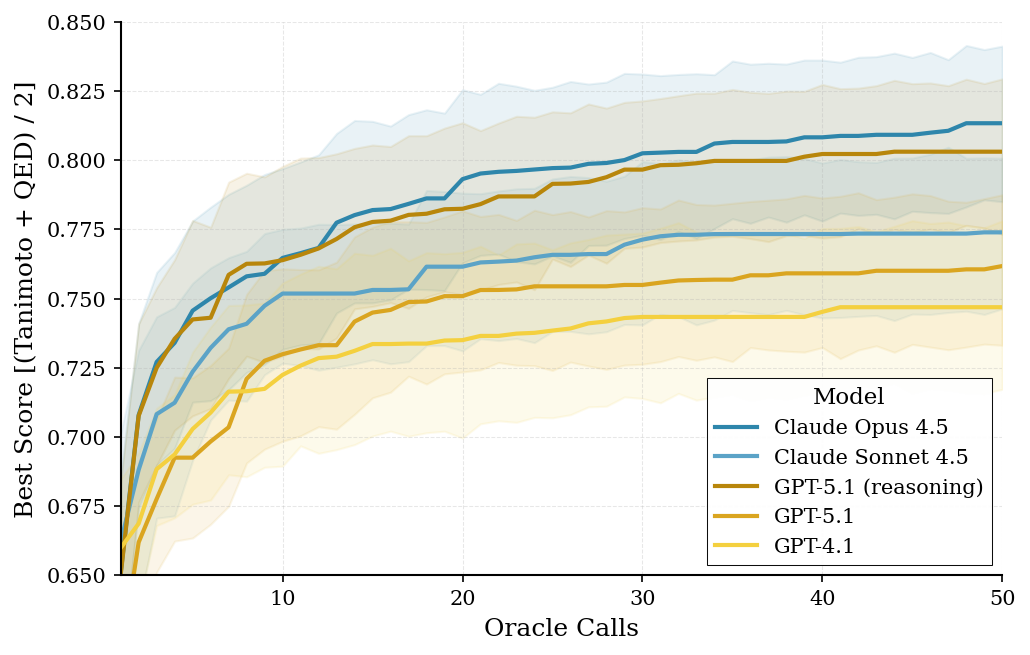

In [6]:
# Compute best-so-far (cummax needs data sorted by iteration)
df["best_so_far"] = (
    df.sort_values("iteration")
    .groupby(["model", "target_molecule"])["score"]
    .cummax()
)

# Pivot so each run is a column, forward-fill to handle runs ending early
max_iter = 50  # Limit to 50 iterations
all_iterations = range(1, max_iter + 1)
df_plot = (
    df[df["iteration"] <= max_iter]
    .pivot_table(index="iteration", columns=["model", "target_molecule"], values="best_so_far")
    .reindex(all_iterations)
    .ffill()
    .melt(ignore_index=False)
    .reset_index()
)

# Set publication-quality style
plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.figsize': (6, 4),
    'axes.linewidth': 1.0,
    'grid.linewidth': 0.5,
    'lines.linewidth': 2.0,
})

# Create figure with better proportions
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)

# Define color palette and publication names for all models in the data
# All GPT models in purple shades, Claude models in blue shades
unique_models = df_plot['model'].unique()
model_colors = {
    'claude-opus-4.5': '#2E86AB',
    'claude-sonnet-4.5': '#5BA3C7',
    'gpt-4.1': '#F4D03F',           # Lightest yellow (brighter)
    'gpt-5.1': '#DAA520',           # Medium yellow (goldenrod)
    'gpt-5.1_reasoning': '#B8860B',  # Darkest yellow (dark goldenrod)
}

# Map internal model names to publication-ready names
model_display_names = {
    'claude-opus-4.5': 'Claude Opus 4.5',
    'claude-sonnet-4.5': 'Claude Sonnet 4.5',
    'gpt-4.1': 'GPT-4.1',
    'gpt-5.1': 'GPT-5.1',
    'gpt-5.1_reasoning': 'GPT-5.1 (reasoning)',
}

# Define legend order
legend_order = [
    'Claude Opus 4.5',
    'Claude Sonnet 4.5',
    'GPT-5.1 (reasoning)',
    'GPT-5.1',
    'GPT-4.1',
]

# Add display names to dataframe
df_plot['model_display'] = df_plot['model'].map(model_display_names)

# Create color palette with display names
display_colors = {model_display_names[k]: v for k, v in model_colors.items() if k in model_display_names}

# Plot with seaborn (mean + 95% bootstrap CI)
sns.lineplot(
    data=df_plot, 
    x="iteration", 
    y="value", 
    hue="model_display",
    hue_order=legend_order,
    palette=display_colors,
    errorbar=('ci', 95),
    err_kws={'alpha': 0.1},  # Make confidence interval more transparent
    linewidth=2.0,
    ax=ax
)

# Styling
ax.set_xlabel("Oracle Calls", fontsize=12, fontweight='normal')
ax.set_ylabel("Best Score [(Tanimoto + QED) / 2]", fontsize=12, fontweight='normal')
ax.set_xlim(1, 50)
ax.set_ylim(0.65, 0.85)
ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Improve legend
legend = ax.legend(
    title='Model',
    frameon=True,
    fancybox=False,
    shadow=False,
    framealpha=0.95,
    edgecolor='black',
    loc='lower right'
)
legend.get_frame().set_linewidth(0.5)

plt.tight_layout()

# Save figure as PDF
plt.savefig('./figures/llm_comparison.pdf', format='pdf', bbox_inches='tight', dpi=300)

plt.show()